In [11]:
import torchvision

# Choose ONE of the root paths as a string
dataset = torchvision.datasets.CIFAR10(
    root='/Users/admin/Documents/spider/task2', 
    train=True, 
    download=True
)

100%|█████████████████████████████████████████| 170M/170M [04:11<00:00, 679kB/s]


In [105]:
import pickle

# 1. Define the function with a generic variable name
def unpickle(file_path):
    # Pass that generic variable into the open() function
    with open(file_path, 'rb') as fo:
        dict1 = pickle.load(fo, encoding='bytes')
    return dict1

# 2. Call the function and pass your specific path as a string (with quotes)
# 3. Assign the returned data to a new variable (my_batch)
my_batch = unpickle('/Users/admin/Documents/spider/task2/cifar-10-batches-py/data_batch_5')

# 4. Verify it loaded correctly
print("Keys in the dictionary:", my_batch.keys())
print("Shape of the image data:", my_batch[b'data'].shape)

Keys in the dictionary: dict_keys([b'batch_label', b'labels', b'data', b'filenames'])
Shape of the image data: (10000, 3072)


In [3]:
import pandas as pd
import numpy as np
import math
import torch.nn.functional as F
import torch.nn as nn
import torch

In [84]:
class ResNet(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.lay1 = nn.Sequential(nn.Conv2d(in_channels=3,out_channels=32,kernel_size = (2,2),stride=2, padding=0,bias = False),nn.BatchNorm2d(32,eps=1e-5,momentum =0.1)) 
        self.lay2 = nn.Sequential(nn.ReLU(),nn.Conv2d(in_channels=32,out_channels=64,kernel_size = (2,2),stride=2, padding=0, bias =False),nn.BatchNorm2d(64,eps=1e-5,momentum =0.1))
        self.lay3 = nn.Sequential(nn.ReLU(),nn.Conv2d(in_channels=64,out_channels=128,kernel_size = (2,2),stride=2, padding=0, bias =False),nn.BatchNorm2d(128,eps=1e-5,momentum =0.1))
        self.short1 = nn.Conv2d(3, 32, kernel_size=1, stride=2)   # must also output 32
        self.short2 = nn.Conv2d(in_channels=32,out_channels=64,kernel_size = (1,1),stride = (2,2),padding =0)
        self.short3 = nn.Conv2d(in_channels=64,out_channels=128,kernel_size = (1,1),stride = (2,2),padding =0)
        self.prob = nn.Sequential(nn.ReLU(),nn.AdaptiveAvgPool2d((1, 1)),nn.Flatten(),nn.Linear(128,10))
    
    def forward(self,x):
        out1 = self.lay1(x)# out dim = 32,3,16,16
        ogx = self.short1(x)
        fin1 = out1 + ogx # out dim = 32,3,16,16
        out2 = self.lay2(fin1) #output dim = 32,3,8,8
        ogx = self.short2(fin1) 
        fin2 = ogx + out2 # out dim = 32,3,8,8
        out3 = self.lay3(fin2)
        ogx = self.short3(fin2)
        fin3 = out3 + ogx
        probs = self.prob(fin3) #out dim = 32,10
        return probs
   

In [106]:

# df shape: (10000, 3, 32, 32)
df = my_batch[b'data'].reshape(10000, 3, 32, 32).astype(np.float32)
df_mean = df.mean(axis=(0, 2, 3), keepdims=True)   # shape (1, 3, 1, 1)
df_std  = df.std(axis=(0, 2, 3), keepdims=True)    # shape (1, 3, 1, 1)
df_norm = (df - df_mean) / df_std   
df_targets = np.array(my_batch[b'labels']).reshape(10000, 1)

In [86]:
model1 = ResNet()

In [87]:
optimizer = torch.optim.AdamW(model1.parameters(), lr=0.001)

In [88]:
def fw(x,target):
        probs = model1(x) #dim = (1,10)
        loss = F.cross_entropy(probs,target)
        return loss

In [123]:
def gen(x):
    probs = model1(x)
    logits = F.softmax(probs)
    id = torch.multinomial(logits,num_samples =1)
    return id

In [ ]:
train_loss=[]

In [ ]:
val_loss=[]

In [113]:
test_loss=[]

In [ ]:
count =0 
model1.train()
batch_size = 32
for i in range(1000):
    optimizer.zero_grad(set_to_none=True)
    index = torch.randint(0,10000-batch_size,size=(1,)).item()
    x = torch.tensor(df_norm[index:index+batch_size,:].reshape(batch_size,3,32,32))
    target = torch.tensor(df_targets[index:index+batch_size,:].squeeze())
    count += 1
    loss = fw(x.float(),target)
    
    loss.backward()
    optimizer.step()
    if (count %100) == 0:
        print(loss.item())
    train_loss.append(loss.item())

In [ ]:
count =0 
model1.eval()
batch_size = 32
for i in range(1000):
    #optimizer.zero_grad(set_to_none=True)
    index = torch.randint(0,5000-batch_size,size=(1,)).item()
    x = torch.tensor(df_norm[index:index+batch_size,:].reshape(batch_size,3,32,32))
    target = torch.tensor(df_targets[index:index+batch_size,:].squeeze())
    count += 1
    loss = fw(x.float(),target)
    
    if (count %100) == 0:
        print(loss.item())
    val_loss.append(loss.item())

In [140]:
acc= 0 
y_t = []
y_p = []
model1.eval()
for x,t in zip(df_norm[5000:],torch.tensor(df_targets[5000:])): #loss calculation and backpropagation
    count+=1
    x = torch.tensor(x.reshape(1,3,32,32))
    id = gen(x.float()).item()
    t = t.item()
    y_t.append(t)
    y_p.append(id)
    print(id,t)
    if id == t:
        acc+=1
        
print(acc/5000)

/var/folders/cq/8d6xzvyx5ndc07c2_z7wjhnc0000gn/T/ipykernel_67825/1242096396.py:3: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  logits = F.softmax(probs)


3 7
1 1
4 4
1 1
9 0
4 2
3 2
5 5
1 9
4 6
0 0
1 1
3 3
1 1
5 1
2 2
0 1
9 8
3 5
2 6
8 9
6 2
4 4
2 2
0 8
8 8
2 3
5 7
1 1
1 7
1 1
4 7
5 5
8 9
7 7
0 0
3 7
8 8
9 3
3 6
2 1
4 2
8 2
5 5
9 9
9 8
2 4
7 8
9 9
7 4
2 2
1 5
9 9
5 3
7 7
9 9
1 9
4 3
1 7
4 9
5 2
5 7
8 8
9 9
4 0
2 7
2 3
2 0
9 1
8 7
1 1
4 4
6 6
8 8
8 2
5 3
5 4
1 1
3 6
6 2
6 6
0 0
5 3
1 5
1 1
4 0
3 9
2 7
0 0
0 0
5 9
2 3
7 4
9 9
1 8
8 8
3 0
1 1
5 6
1 1
2 4
1 9
5 0
2 7
3 8
8 1
0 0
9 9
2 5
1 2
0 4
2 4
3 7
9 0
2 4
0 8
9 9
3 3
1 1
3 2
2 2
7 4
5 4
2 0
6 4
5 5
1 1
7 7
5 3
4 5
5 7
2 2
8 4
4 4
3 5
5 6
5 4
3 3
8 8
4 4
6 6
6 6
4 5
0 0
3 4
4 9
5 9
7 7
0 8
1 6
9 7
2 3
2 3
2 5
3 9
6 6
0 0
4 1
6 3
8 8
7 9
8 8
8 8
0 0
2 6
6 6
0 0
1 9
8 8
6 6
4 4
7 7
0 7
9 9
9 9
3 3
7 0
3 9
4 5
3 5
3 6
2 5
1 0
7 9
9 5
8 8
8 0
1 1
0 0
3 4
4 0
3 3
7 3
7 2
9 1
9 1
2 4
1 9
1 9
2 4
4 2
1 1
9 1
3 2
4 7
3 4
2 5
3 5
3 6
3 3
9 1
2 3
1 1
8 2
1 1
7 5
5 3
4 3
2 2
3 5
2 6
4 4
7 5
6 2
5 7
4 6
7 4
6 6
1 1
2 2
9 7
9 9
9 0
9 0
2 4
9 9
5 3
4 5
2 2
2 4
8 8
9 9
0 0
8 8
0 2
4 5
2 1
6 6
6 6
5 3


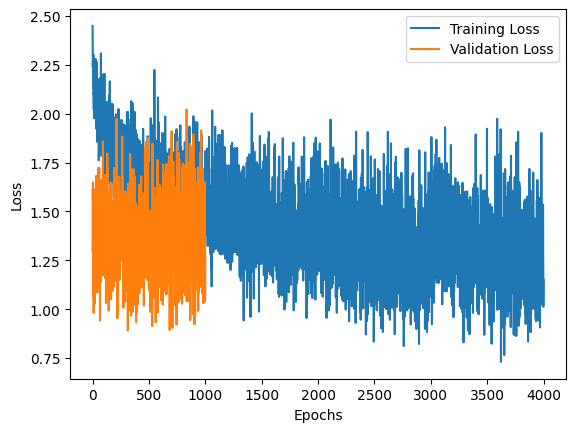

In [117]:
import matplotlib.pyplot as plt
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
#plt.plot(test_loss, label='test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

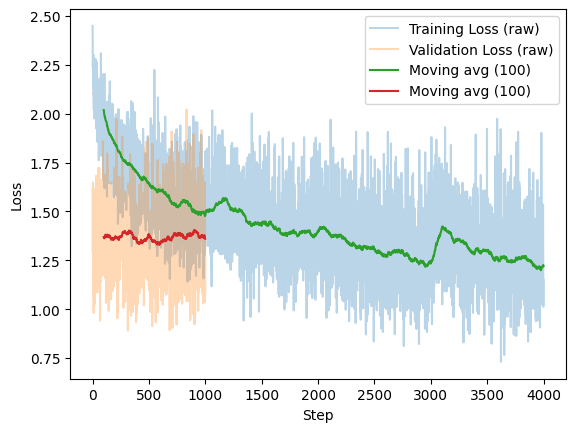

In [120]:
import matplotlib.pyplot as plt
import numpy as np

window = 100
smoothed_train = np.convolve(train_loss, np.ones(window)/window, mode='valid')
smoothed_val = np.convolve(val_loss, np.ones(window)/window, mode='valid')
#smoothed_test = np.convolve(test_loss, np.ones(window)/window, mode='valid')

plt.plot(train_loss, alpha=0.3, label='Training Loss (raw)')
plt.plot(val_loss, alpha=0.3, label='Validation Loss (raw)')
#plt.plot(test_loss, alpha=0.3, label='test Loss (raw)')
plt.plot(range(window-1, len(train_loss)), smoothed_train, label=f'Moving avg ({window})')
plt.plot(range(window-1, len(val_loss)), smoothed_val, label=f'Moving avg ({window})')
#plt.plot(range(window-1, len(test_loss)), smoothed_test, label=f'Moving avg ({window})')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [144]:
from sklearn.metrics import classification_report

num_classes = 10
class_names = [f"Class {i}" for i in range(num_classes)]
print(classification_report(y_t, y_p, target_names=class_names))

              precision    recall  f1-score   support

     Class 0       0.43      0.39      0.41       493
     Class 1       0.48      0.51      0.50       488
     Class 2       0.23      0.29      0.26       479
     Class 3       0.25      0.28      0.26       519
     Class 4       0.31      0.29      0.30       475
     Class 5       0.30      0.31      0.31       529
     Class 6       0.48      0.36      0.41       488
     Class 7       0.42      0.28      0.34       485
     Class 8       0.53      0.52      0.53       532
     Class 9       0.43      0.55      0.48       512

    accuracy                           0.38      5000
   macro avg       0.39      0.38      0.38      5000
weighted avg       0.39      0.38      0.38      5000



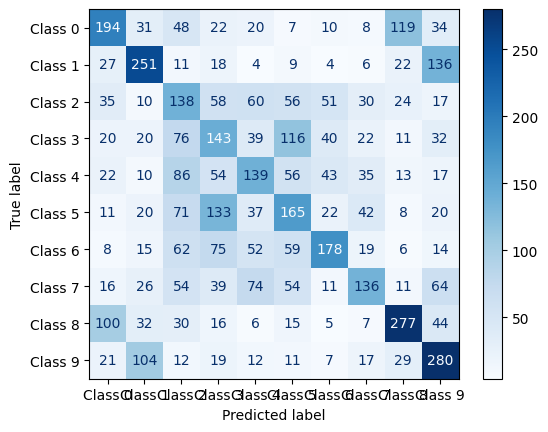

In [145]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_t, y_p)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [146]:
# Save the weights
torch.save(model1.state_dict(), 'my_model_weights.pth')
# model1 = MyNeuralNetwork()
# model1.load_state_dict(torch.load('my_model_weights.pth'))

In [ ]:
#explanation of design choices
''''''